In [4]:
#!/usr/bin/env python
import matplotlib.pyplot as plt
from random import random

def statisch(need,have):
    """
    Die verfügbare Energiemenge (have) wird zu gleichen Teilen auf die
    Teilnehmer aufgeteilt. Anteile, die den jeweiligen Bedarf (need[])
    übertreffen, werden nicht vollständig zugeteilt.
    """
    havePP = have/len(need)
    give = [havePP if havePP < n else n for n in need]
    return give

def dynamisch2(need,have):
    """
    Die verfügbare Energiemenge (have) wird entsprechend dem Anteil des
    jeweiligen Nutzers am Gesamtenergieverbrauch (need[i]/sum(need)) zugeteilt.
    """
    allneed=sum(need)
    give = [n/allneed * have for n in need]
    give = [n if n < g else g for n,g in zip(need,give)]
    return give

def dynamisch(need,have):
    """
    Die verfügbare Energiemenge (have) wird entsprechend dem Anteil des
    jeweiligen Nutzers am Gesamtenergieverbrauch (need[i]/sum(need)) zugeteilt.
    Equivalent: Alle Teilnehmer erhalten einen festen relativen Anteil ihres
    Verbrauchs entsprechend dem Verhältnis zwischen verfügbarer Energiemenge
    und Gesamtverbrauch
    """
    factor = min(1.0,have/sum(need))
    give = [n*factor for n in need]
    return give

def konservativ(need,have):
    """
    Die Energiemenge (have) wird bis zur Größe der Summe der Verbräuche aller
    Teilnehmer (need[]) vollständig so verteilt, dass kein Teilnehmer
    weniger erhält als irgendein anderer Teilnehmer, es sei denn, sein
    Verbrauch (der des ersteren) kann bereits vollständig gedeckt werden.
    """
    nleft=len(need)
    haveleft = have
    havePP = haveleft/nleft
    give = need.copy()
    # argsort(need):
    for i in sorted(range(len(need)),key=lambda j:need[j]):
        if need[i] > havePP:
            give[i] = havePP
        else:
            # give[i] = need[i] # already set via .copy() above
            haveleft -= need[i]
            nleft -= 1
            if nleft > 0:
                havePP = haveleft/nleft
    return give


def plotGGV(ErzeugungkWh=6.0,Schluessel="s",ZufallsVerbrauch=False):
    global verbrauch, prevZuf
    Emake = ErzeugungkWh
    xtext = 0.66
    ytext = 0.82
    plt.figure(1)
    plt.ylabel("Verbrauch in kWh")
    plt.xlabel("TN")

    if ZufallsVerbrauch:
        verbrauch = [random() for _ in range(6)]
    else: 
        verbrauch = [0.5,0.7,1.2,1.3,1.8,3.9]
        
    verbrauch.sort()
    Eneed=sum(verbrauch)
    #print("Verbrauch: %.2f kWh"%Eneed)
    needPP = Eneed/len(verbrauch)

    bneed=plt.bar(range(1,1+len(verbrauch)),verbrauch,edgecolor="#4000E0FF",facecolor="#e4d9ffff",zorder=2)
    ftxt=plt.figtext(xtext,ytext,"Verbraucht: %.2f kWh (⌀ %.2f kWh pro TN)"%(Eneed,needPP),va="top",ha="right")

    makePP = Emake / len(verbrauch)
    ftxt._text+="\nErzeugt: %.2f kWh (⌀ %.2f kWh pro TN)"%(Emake,makePP)
    hl=plt.hlines([Emake/len(verbrauch)],0.6,6.4,color="k",linestyle="--",lw=0.5,zorder=1)

    if Schluessel[0] not in ["s","d","k"]:
        Schluessel = "s"
    if Schluessel.startswith("s"):
        vertfunc = statisch
        verttxt = "Statischer Schlüssel"
    if Schluessel.startswith("d"):
        vertfunc = dynamisch
        verttxt = "Dynamischer Schlüssel"
    if Schluessel.startswith("k") or Schluessel.endswith("chwäbisch"):
        vertfunc = konservativ
        verttxt = "Konservativer Schlüssel"
    ftxt._text += "\n"+verttxt

    solaranteil=vertfunc(verbrauch,Emake)
    Everteilt=sum(solaranteil)
    bgive=plt.bar(range(1,1+len(solaranteil)),solaranteil,edgecolor="#0808E0FF",facecolor="#0808E060",zorder=3)

    Eeinsp=Emake-Everteilt
    ftxt._text += ", zugeteilt: %.2f kWh"%Everteilt
    ftxt._text += "\nnicht zugeteilt: %.2f kWh"%max(0,Eeinsp)
    Everteilbar = min(Eneed,Emake)
    if Eeinsp >= 0.01:
        ftxt._text += "\ndavon theoretisch noch zuteilbar: %.2f kWh"%max(0,Everteilbar-Everteilt)

    annos = []
    if Eeinsp >= 0.01 and Emake <= Eneed:
        for i,g in enumerate(solaranteil):
            if g < makePP:
                a=plt.annotate("",xytext=(i+1,g),xy=(i+1,makePP),arrowprops=dict(arrowstyle="|-|",color="#C02020FF",linewidth=3.0))
                annos.append(a)

In [6]:
from ipywidgets import interact,fixed
w=interact(plotGGV,Erzeugung=(0,20.0),Schluessel=["statisch","dynamisch","konservativ"],ZufallsVerbrauch=fixed(False))

interactive(children=(FloatSlider(value=6.0, description='ErzeugungkWh', max=18.0, min=-6.0), Dropdown(descrip…

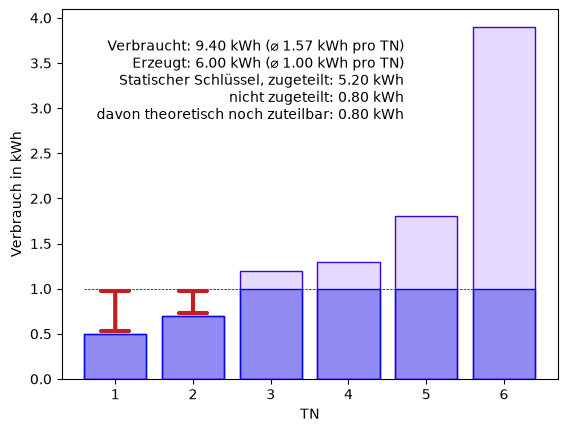

In [10]:
plotGGV(6.0,"statisch")

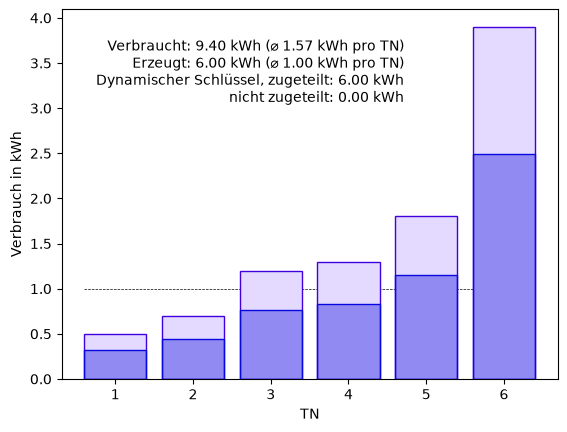

In [11]:
plotGGV(6.0,"dynamisch")

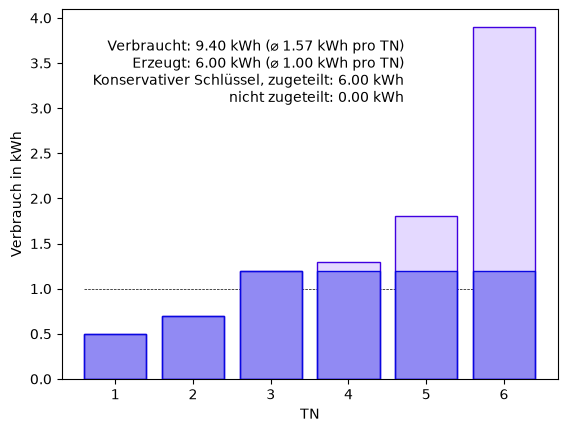

In [14]:
plotGGV(6.0,"schwäbisch")